### 导入需要的包

In [1]:
import torch
import os
import random
import gymnasium as gym
import numpy as np
import seaborn as sns
import torch.nn as nn
import torch.utils.data as Data
from matplotlib import pyplot as plt
from torch.nn import functional as F
from torch.distributions import Categorical,Normal
from collections import deque

### 定义演员-评论家网络

针对简单的离散动作空间环境，可以通过线性层+激活层的方式实现，这里还给出了ActorNormal网络，用于连续动作空间。下面只针对离散动作空间进行实现。

In [2]:
class ActorSoftmax(nn.Module):
    def __init__(self,input_dim, output_dim, hidden_dim=256):
        super(ActorSoftmax,self).__init__()
        self.fc1 = nn.Linear(input_dim,hidden_dim)
        self.fc2 = nn.Linear(hidden_dim,hidden_dim)
        self.fc3 = nn.Linear(hidden_dim,output_dim)
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        probs = F.softmax(self.fc3(x), dim = 1)
        return probs

class ActorNormal(nn.Module):
    def __init__(self, n_states,n_actions, hidden_dim=256):
        super(ActorNormal, self).__init__()
        self.fc1 = nn.Linear(n_states, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, n_actions)
        self.fc4 = nn.Linear(hidden_dim, n_actions)
    def forward(self,x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        mu = torch.tanh(self.fc3(x)) # 正态分布的均值，范围[-1,1]
        sigma = F.softplus(self.fc4(x)) + 0.001 # 正态分布的方差，加上0.001避免0的情况出现
        sigma = torch.clamp(sigma, min=-0.25, max=0.25) # 限制方差范围
        return mu,sigma
    
class Critic(nn.Module):
    def __init__(self,input_dim, output_dim, hidden_dim=256):
        super(Critic,self).__init__()
        self.fc1 = nn.Linear(input_dim,hidden_dim)
        self.fc2 = nn.Linear(hidden_dim,hidden_dim)
        self.fc3 = nn.Linear(hidden_dim,output_dim)
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        value = self.fc3(x)
        return value

### 定义智能体-PPO算法的实现

首先定义一个缓冲区，用于收集展开n_steps的轨迹，环境会根据选取的动作返回新的观测状态、奖励等信息。将这些信息存储在缓冲区内，在下面PPO算法的实现中，每当存储了train_batch_size步的轨迹产生的信息之后，将它们全部取出，进行网络的k轮更新。

In [3]:
class PGReplay:
    '''创建一个缓冲区，用于策略梯度算法，每当智能体在环境中执行n步动作之后，将缓冲区中存储的信息全部提取出来计算进行网络参数更新
    '''
    def __init__(self):
        self.buffer = deque() # 创建一个缓冲区
    def push(self,transitions):
        self.buffer.append(transitions) # 将transition存储到缓冲区中
    def sample(self):
        batch = list(self.buffer)
        return zip(*batch) # 提取出所有的transition
    def clear(self):
        self.buffer.clear() # 清空缓冲区

首先，PPO算法要解决的问题是策略梯度在算法更新和数据利用上不够高效的问题。在策略梯度的实现过程中，利用策略${\pi}_{\theta}$采样到多个轨迹的数据，对网络参数$\theta$进行更新，但每次更新之后相应的概率${p}_{\theta}{(\tau)}$就变了，从而需要重新采样数据，再用新的数据进行更新。显然，这是低效的，且对数据的利用率很低。

以下是PPO算法的具体实现过程。PPO算法的核心是利用了重要性采样的思想。为了使智能体与环境的交互更加高效，先用一个策略${\pi}_{{\theta}^{'}}$以及演员${\theta}^{'}$和环境进行交互，保存产生的多条轨迹信息，然后用${\theta}^{'}$采样到的数据去训练$\theta$。如此，每当${\theta}^{'}$采样一次，并采样多一点的数据，我们就可以多次使用${\theta}^{'}$采样到的数据去训练$\theta$，并且每次都只需要同一批数据进行梯度上升（gradient ascent），从而实现多次更新参数。

由于策略不同，所以对应的${p}_{\theta}({a_t}|{s_t})$与$p_{{\theta}^{'}}(a_t|s_t)$也会存在差异。根据重要性采样的原理，两个分布的差异不能太大，否则重要性采样的结果就会不好。因此在PPO算法中引入近端策略优化惩罚（PPO-penalty）和近端策略优化裁剪（PPO-clip）两个技术。

在PPO-penalty算法中，在原本优化目标的基础上，加入一个KL散度值，与正则化类似，相当于在损失函数的基础上加一个惩罚项，用于限制$\theta$和${\theta}^{'}$的区别；在PPO-clip算法中，同样也是对优化目标函数进行修改，直接利用裁剪函数来限制${p}_{\theta}({a_t}|{s_t})$与$p_{{\theta}^{'}}(a_t|s_t)$之间的差别。以上两种方法都可以直接通过调用函数来实现。

In [4]:
class PPO:
    def __init__(self,cfg):
        self.ppo_type = cfg.ppo_type
        ## 定义kl散度相关参数
        if self.ppo_type == 'kl':
            self.kl_target = cfg.kl_target
            self.kl_lambda = cfg.kl_lambda
            self.kl_beta = cfg.kl_beta
            self.kl_alpha = cfg.kl_alpha
        self.gamma = cfg.gamma
        self.device = torch.device(cfg.device)
        self.continuous = cfg.continuous
        self.action_space = cfg.action_space
        ## 定义连续动作空间下的actor网络
        if self.continuous:
            self.action_scale = torch.tensor((self.action_space.high-self.action_space.low)/2,device=self.device,dtype=torch.float32).unsqueeze(dim=0)
            self.action_bias =  torch.tensor((self.action_space.high+self.action_space.low)/2,device=self.device,dtype=torch.float32).unsqueeze(dim=0)
            self.actor = ActorNormal(cfg.state_dim, cfg.action_dim, hidden_dim=cfg.actor_hidden_dim).to(self.device)
        ## 定义离散动作空间下的actor网络
        else:
            self.actor = ActorSoftmax(cfg.state_dim, cfg.action_dim, hidden_dim=cfg.critic_hidden_dim).to(self.device)
        ## 定义critic网络和优化器
        self.critic = Critic(cfg.state_dim, 1, hidden_dim=cfg.critic_hidden_dim).to(self.device)
        self.actor_optimizer = torch.optim.Adam(self.actor.parameters(),lr=cfg.actor_lr)
        self.critic_optimizer = torch.optim.Adam(self.critic.parameters(),lr=cfg.critic_lr)
        self.memory = PGReplay() # 定义缓冲区
        self.k_epochs = cfg.k_epochs # 每次更新网络的轮数
        self.eps_clip = cfg.eps_clip # 裁剪函数参数
        self.entropy_coef = cfg.entropy_coef # 策略熵正则参数
        self.sample_count = 0 # 用于采样次数计数
        self.train_batch_size = cfg.train_batch_size # 更新网络收集的轨迹数
        self.sgd_batch_size = cfg.sgd_batch_size # 每轮更新采用的数据量
    def sample_action(self, state):
        '''动作采样函数
        '''
        self.sample_count += 1
        ## 连续动作空间采样
        if self.continuous:
            state = torch.tensor(state, device=self.device, dtype=torch.float32).unsqueeze(dim=0)
            mu, sigma = self.actor(state)
            mean = mu * self.action_scale + self.action_bias
            std = sigma
            dist = Normal(mean, std)
            action = dist.sample()
            action = torch.clamp(action, torch.tensor(self.action_space.low, device=self.device, dtype=torch.float32), torch.tensor(self.action_space.high, device=self.device, dtype=torch.float32))
            self.log_probs = dist.log_prob(action).detach()
            return action.detach().cpu().numpy()[0]
        ## 离散动作空间采样
        else:
            state = torch.tensor(state, device=self.device, dtype=torch.float32).unsqueeze(dim=0)
            probs = self.actor(state)
            dist = Categorical(probs)
            action = dist.sample()
            self.probs = probs.detach()
            self.log_probs = dist.log_prob(action).detach()
            return action.detach().cpu().numpy().item()
    @torch.no_grad()
    def predict_action(self, state):
        '''预测动作，与动作采样函数功能相同，只是执行该函数时不需要计算梯度
        '''
        if self.continuous:
            state = torch.tensor(state, device=self.device, dtype=torch.float32).unsqueeze(dim=0)
            mu, sigma = self.actor(state)
            mean = mu * self.action_scale + self.action_bias
            std = sigma
            dist = Normal(mean, std)
            action = dist.sample()
            self.log_probs = dist.log_prob(action).detach()
            return action.detach().cpu().numpy()[0]
        else:
            state = torch.tensor(state, device=self.device, dtype=torch.float32).unsqueeze(dim=0)
            probs = self.actor(state)
            dist = Categorical(probs)
            action = dist.sample()
            self.log_probs = dist.log_prob(action).detach()
            return action.detach().cpu().numpy().item()
    def _compute_returns(self, rewards, dones):
        '''计算一个轨迹的累计奖励
        '''
        returns = []
        discounted_reward = 0
        for reward, done in zip(reversed(rewards),reversed(dones)):
            if done:
                discounted_reward = 0
            discounted_reward = reward + self.gamma * discounted_reward
            returns.insert(0, discounted_reward)
        # 归一化处理，使数值更加稳定
        returns = torch.tensor(returns, device=self.device, dtype=torch.float32).unsqueeze(dim=1) # shape:[train_batch_size,1]
        returns = (returns - returns.mean())/(returns.std()+1e-5) # 避免除0
        return returns
    def update(self):
        # 每采集train_batch_size条数据即进行更新
        if self.sample_count % self.train_batch_size != 0:
            return
        states, actions, rewards, dones, probs, log_probs = self.memory.sample()
        ## 数据转为tensor类型，并统一shape便于后续计算
        states = torch.tensor(np.array(states), device=self.device, dtype=torch.float32) # shape:[train_batch_size,state_dim]
        actions = torch.tensor(np.array(actions), device=self.device, dtype=torch.float32).unsqueeze(dim=1) # shape:[train_batch_size,1]
        rewards = torch.tensor(np.array(rewards), device=self.device,dtype=torch.float32).unsqueeze(dim=1) # shape:[train_batch_size,1]
        dones = torch.tensor(np.array(dones), device=self.device,dtype=torch.float32).unsqueeze(dim=1) # shape:[train_batch_size,1]
        probs = torch.cat(probs).to(self.device) # shape:[train_batch_size,action_dim]
        log_probs = torch.tensor(log_probs, device=self.device,dtype=torch.float32).unsqueeze(dim=1) # shape:[train_batch_size,1]
        returns = self._compute_returns(rewards, dones) # shape:[train_batch_size,1]
        # 利用dataloader保存和加载数据
        dataset = Data.TensorDataset(states, actions, probs, log_probs, returns)
        train_loader = Data.DataLoader(dataset=dataset, batch_size=self.sgd_batch_size, shuffle=True,drop_last=False)      
        ## 每次取出sgd_batch_size条数据进行更新
        for _ in range(self.k_epochs):
            for batch_idx, (old_states, old_actions, old_probs, old_log_probs, returns) in enumerate(train_loader):
                # 计算优势值
                values = self.critic(old_states)
                advantages = returns - values.detach()
                ## 计算新的动作概率分布
                if self.continuous:
                    mu, sigma = self.actor(old_states)
                    mean = mu * self.action_scale + self.action_bias
                    std = sigma
                    dist = Normal(mean, std)
                    new_log_probs = dist.log_prob(old_actions)
                else:
                    new_probs = self.actor(old_states)
                    dist = Categorical(new_probs)
                    new_log_probs = dist.log_prob(old_actions.squeeze(dim=1)) # shape:[train_batch_size,1]
                # 计算两个概率之间的差异：(pi_theta / pi_theta_old)
                ratio = torch.exp(new_log_probs.unsqueeze(dim=1) - old_log_probs) # shape:[train_batch_size,1]
                # 计算surrogate loss
                surr1 = ratio * advantages # shape:[train_batch_size,1]
                ## PPO-clip方法
                if self.ppo_type == 'clip':
                    surr2 = torch.clamp(ratio, 1 - self.eps_clip, 1 + self.eps_clip) * advantages
                    actor_loss = - (torch.min(surr1, surr2).mean() + self.entropy_coef * dist.entropy().mean())
                ## PPO-kl方法
                elif self.ppo_type == 'kl':
                    kl_mean = F.kl_div(torch.log(new_probs.detach()), old_probs.unsqueeze(dim=1), reduction='mean')
                    surr2 = self.kl_lambda * kl_mean
                    actor_loss = - (surr1.mean() + surr2 + self.entropy_coef * dist.entropy().mean())
                    ## 动态调整KL散度加权系数
                    if kl_mean > self.kl_beta * self.kl_target:
                        self.kl_lambda *= self.kl_alpha
                    elif kl_mean < 1/self.kl_beta * self.kl_target:
                        self.kl_lambda /= self.kl_alpha
                else:
                    raise NameError("ppo_type must be 'clip' or 'kl'")
                # 计算critic loss
                critic_loss = nn.MSELoss()(returns, values)
                ## 更新参数
                self.actor_optimizer.zero_grad()
                self.critic_optimizer.zero_grad()
                actor_loss.backward()
                critic_loss.backward()
                self.actor_optimizer.step()
                self.critic_optimizer.step()        
        self.memory.clear() # 清空缓冲区

### 定义训练

In [5]:
def train(cfg, env, agent):
    ''' 训练
    '''
    print("开始训练！")
    rewards = []  # 记录所有回合的奖励
    steps = [] # 记录所有回合的步数
    for i_ep in range(cfg.train_eps):
        ep_reward = 0  # 记录一回合内的奖励
        ep_step = 0 # 记录一回合智能体一共走的步数
        state, info = env.reset(seed = cfg.seed)  # 重置环境，返回初始状态
        for _ in range(cfg.max_steps):
            ep_step += 1
            action = agent.sample_action(state)  # 动作采样
            next_state, reward, terminated, truncated , info = env.step(action)  # 更新环境，返回transition        
            agent.memory.push((state, action, reward, terminated, agent.probs, agent.log_probs)) # 将transition存储到缓冲区中
            agent.update() # 更新网络参数
            state = next_state  # 更新状态
            ep_reward += reward  # 计算累积奖励
            if terminated:
                break
        steps.append(ep_step)
        rewards.append(ep_reward)
        if (i_ep + 1) % 10 == 0:
            print(f"回合：{i_ep+1}/{cfg.train_eps}，奖励：{ep_reward:.2f}")
    print("完成训练！")
    env.close()
    return {'rewards':rewards}

def test(cfg, env, agent):
    print("开始测试！")
    rewards = []  # 记录所有回合的奖励
    steps = [] # 记录所有回合的步数
    for i_ep in range(cfg.test_eps):
        ep_reward = 0  # 记录一回合内的奖励
        ep_step = 0 # 记录一回合智能体一共走的步数
        state, info = env.reset(seed = cfg.seed)  # 重置环境，返回初始状态
        for _ in range(cfg.max_steps):
            ep_step+=1
            action = agent.predict_action(state)  # 选择动作
            next_state, reward, terminated, truncated , info = env.step(action)  # 更新环境，返回transition
            state = next_state  # 更新下一个状态
            ep_reward += reward  # 累加奖励
            if terminated:
                break
        steps.append(ep_step)
        rewards.append(ep_reward)
        print(f"回合：{i_ep+1}/{cfg.test_eps}，奖励：{ep_reward:.2f}")
    print("完成测试")
    env.close()
    return {'rewards':rewards}

### 定义环境

In [6]:
def all_seed(seed = 1):
    ''' 万能的seed函数
    '''
    if seed == 0: # 不设置seed
        return 
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed) # config for CPU
    torch.cuda.manual_seed(seed) # config for GPU
    os.environ['PYTHONHASHSEED'] = str(seed) # config for python scripts
    # config for cudnn
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.enabled = False
def env_agent_config(cfg):
    env = gym.make(cfg.env_id) # 创建环境
    all_seed(seed=cfg.seed) # 设置随机种子
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n
    print(f"状态空间维度：{state_dim}，动作空间维度：{action_dim}")
    setattr(cfg,"state_dim",state_dim) # 更新state_dim到cfg参数中
    setattr(cfg,"action_dim",action_dim) # 更新action_dim到cfg参数中
    setattr(cfg,"action_space",env.action_space)
    agent = PPO(cfg)
    return env,agent

### 设置参数

In [7]:
class Config:
    def __init__(self) -> None:
        self.algo_name = 'PPO' # 算法名称
        self.env_id = 'CartPole-v1' # 环境id
        self.seed = 1 # 随机种子，便于复现，0表示不设置
        self.continuous = False # 设置动作空间是离散还是连续的
        self.ppo_type = 'clip' # 选择PPO-clip或者PPO-penalty算法
        if self.ppo_type == 'kl':
            self.kl_target = 0.1 # KL散度基准值
            self.kl_lambda = 0.5 # KL散度正则项系数初始值
            self.kl_beta = 1.5 # 用于计算基准值
            self.kl_alpha = 2 # 用于调整正则项系数
        self.continuous = False # 设置动作空间为连续还是离散
        self.k_epochs = 4 # 每次更新参数的轮数
        self.train_eps = 200 # 训练的回合数
        self.test_eps = 20 # 测试的回合数
        self.max_steps = 200 # 每个回合的最大步数，超过该数则游戏强制终止
        self.gamma = 0.95 # 折扣因子
        self.actor_lr = 3e-4 # actor网络学习率
        self.critic_lr= 1e-3 # critic网络学习率
        self.eps_clip = 0.2 # PPO-clip中的裁剪函数参数
        self.entropy_coef = 0.001 # 损失函数中entropy_loss的系数值
        self.actor_hidden_dim = 256 # actor网络的隐藏层维度
        self.critic_hidden_dim = 256 # critic网络的隐藏层维度
        self.train_batch_size = 256 # 采样一次数据的步数
        self.sgd_batch_size = 32 # 更新一次数据的batch大小
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # 检测gpu
        
def smooth(data, weight=0.9):  
    '''用于平滑曲线，类似于Tensorboard中的smooth曲线
    '''
    last = data[0] 
    smoothed = []
    for point in data:
        smoothed_val = last * weight + (1 - weight) * point  # 计算平滑值
        smoothed.append(smoothed_val)                    
        last = smoothed_val                                
    return smoothed

def plot_rewards(rewards,cfg, tag='train'):
    ''' 画图
    '''
    sns.set()
    plt.figure()  # 创建一个图形实例，方便同时多画几个图
    plt.title(f"{tag}ing curve on {cfg.device} of {cfg.algo_name} for {cfg.env_id}")
    plt.xlabel('epsiodes')
    plt.plot(rewards, label='rewards')
    plt.plot(smooth(rewards), label='smoothed')
    plt.legend()
    plt.show()

### 开始训练

状态空间维度：4，动作空间维度：2
开始训练！
回合：10/200，奖励：11.00
回合：20/200，奖励：29.00
回合：30/200，奖励：42.00
回合：40/200，奖励：143.00
回合：50/200，奖励：44.00
回合：60/200，奖励：157.00
回合：70/200，奖励：200.00
回合：80/200，奖励：200.00
回合：90/200，奖励：127.00
回合：100/200，奖励：162.00
回合：110/200，奖励：200.00
回合：120/200，奖励：154.00
回合：130/200，奖励：162.00
回合：140/200，奖励：117.00
回合：150/200，奖励：196.00
回合：160/200，奖励：60.00
回合：170/200，奖励：179.00
回合：180/200，奖励：143.00
回合：190/200，奖励：200.00
回合：200/200，奖励：200.00
完成训练！


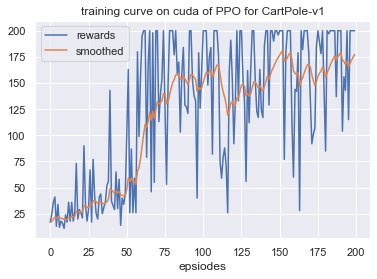

开始测试！
回合：1/20，奖励：200.00
回合：2/20，奖励：153.00
回合：3/20，奖励：200.00
回合：4/20，奖励：200.00
回合：5/20，奖励：200.00
回合：6/20，奖励：200.00
回合：7/20，奖励：200.00
回合：8/20，奖励：200.00
回合：9/20，奖励：200.00
回合：10/20，奖励：200.00
回合：11/20，奖励：200.00
回合：12/20，奖励：200.00
回合：13/20，奖励：200.00
回合：14/20，奖励：200.00
回合：15/20，奖励：200.00
回合：16/20，奖励：193.00
回合：17/20，奖励：200.00
回合：18/20，奖励：200.00
回合：19/20，奖励：200.00
回合：20/20，奖励：200.00
完成测试


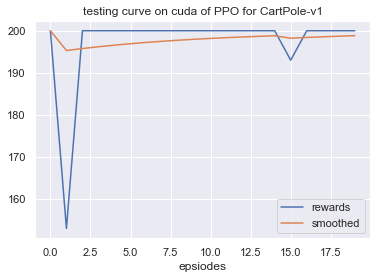

In [8]:
# 获取参数
cfg = Config() 
# 训练
env, agent = env_agent_config(cfg)
res_dic = train(cfg, env, agent)
plot_rewards(res_dic['rewards'], cfg, tag="train")  
# 测试
res_dic = test(cfg, env, agent)
plot_rewards(res_dic['rewards'], cfg, tag="test")  # 画出结果